# Iteration 2: Multi-Model Embedding Comparison — RQ1 
**Research Questions:** RQ1 (Process-safety classification)

**Objective:** Systematically compare six BERT-family transformer models — BERT-base-cased, BERT-large-cased, RoBERTa-base, RoBERTa-large, DistilBERT-base-cased, and XLNet-base-cased — as feature extractors for binary classification of incident reports. Each model generates `[CLS]` token embeddings that are classified by a LinearSVC with balanced class weights. Performance is evaluated across four country-level datasets (English, Germany, Sweden, Netherlands), yielding 24 model–dataset combinations. This iteration directly addresses RQ2 by establishing a comparative baseline across architectures and informs RQ1 by identifying the best-performing embedding model.

**Outputs:** Cached embeddings (`.pkl`), confusion matrices (PNG + PDF), classification reports, `iteration_2_summary.json`, and `all_models_svm_detailed_results.json`.

---

## 1. Configuration, Path Resolution, and Data Loading
This section initialises the environment for reproducible multi-model analysis. Cross-platform path resolution ensures portability, output directories for embeddings and results are created automatically, and the master dataset (pre-processed in Iteration 0) is loaded. A dictionary of available country-level dataset files is built, and checkpoint/reset utilities enable resumable execution across model–dataset combinations.

In [7]:
# ============================================================
# RESTART UTILITIES - Iteration 2
# ============================================================

import os
import json
import glob
import shutil
from pathlib import Path
from typing import Union, Optional
import pandas as pd

# Cross-platform path resolution (consistent with Iteration 0 & 1)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())

PATHS = {
    'master_dataset':   BASE_DIR / "Master Dataset 34k",
    'embeddings':       BASE_DIR / "Embeddings" / "_iteration_2",
    'results':          BASE_DIR / "Results" / "_iteration_2"
}

# Normalize all paths
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR            = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR         = str(PATHS['results'])
CHECKPOINT_FILE     = str(PATHS['results'] / "checkpoint_iteration_2.json")

# =============================================================================
# Language code mapping (consistent with Iteration 0)
# =============================================================================
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}

# =============================================================================
# Load Master Dataset (pre-processed in Iteration 0)
# =============================================================================
master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f"Loaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns")


DATASET_FILES = {
    'english_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'germany_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'sweden_manual':        str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'netherlands_manual':   str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}
# Only include files that exist
DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if os.path.exists(v)}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")


def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"Processed combinations: {len(processed)}")
            print("\nCompleted:")
            for item in processed:
                # Handle both tuple formats: (model, dataset) or single values
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"  - {model:20s} → {dataset}")
                else:
                    print(f"  - {item}")
    else:
        print("No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f"  Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("All embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print("Embeddings directory doesn't exist")

def reset_results():
    """Delete all results"""
    if os.path.exists(RESULTS_DIR):
        response = input(f"  Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print("All results deleted")
        else:
            print("Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("="*60)
    print(" FULL RESET WARNING")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific model
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")


def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific dataset
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print("Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('modernbert-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print("RESTART UTILITIES LOADED")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("\nTIP: To completely restart everything, run: complete_rerun()")
print("="*60)

Loaded master_df: 34,576 records, 36 columns
Dataset files available: ['english_manual', 'germany_manual', 'sweden_manual', 'netherlands_manual']
No checkpoint found - no progress yet

RESTART UTILITIES LOADED
Available functions:
  view_progress()              - See what's completed
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

TIP: To completely restart everything, run: complete_rerun()


## 2. (Optional) Complete Rerun Command
Uncomment the command below to trigger a complete pipeline reset — clearing all checkpoints, embeddings, and results. This is useful when re-running the full experiment from scratch after code changes.

In [8]:
#complete_rerun()

## 3. Multi-Model Embedding Generation and SVM Evaluation Pipeline
This section defines and executes the main experimental pipeline. For each of the six BERT-family models, `[CLS]` token embeddings are generated (or loaded from cache) for every dataset. A LinearSVC with balanced class weights is trained on each embedding set, and evaluation metrics — accuracy, macro-F1, per-class precision/recall, and confusion matrices — are computed. Confusion matrices are saved as separate, high-resolution figures (PNG + PDF). A checkpoint mechanism enables resumable execution across model–dataset combinations.


################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Datasets to process: 4
  english_manual: master_df_English_manual.json
  germany_manual: master_df_Germany_manual.json
  sweden_manual: master_df_Sweden_manual.json
  netherlands_manual: master_df_Netherlands_manual.json

Found 6 models to use
Total combinations: 24
Already processed: 0 combinations

################################################################################
MODEL: bert-base-cased (bert-base-cased)
################################################################################

Initializing bert-base-cased...
Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-cased

[SKIP] Embeddings already exist: english_manual | Model: bert-base-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/

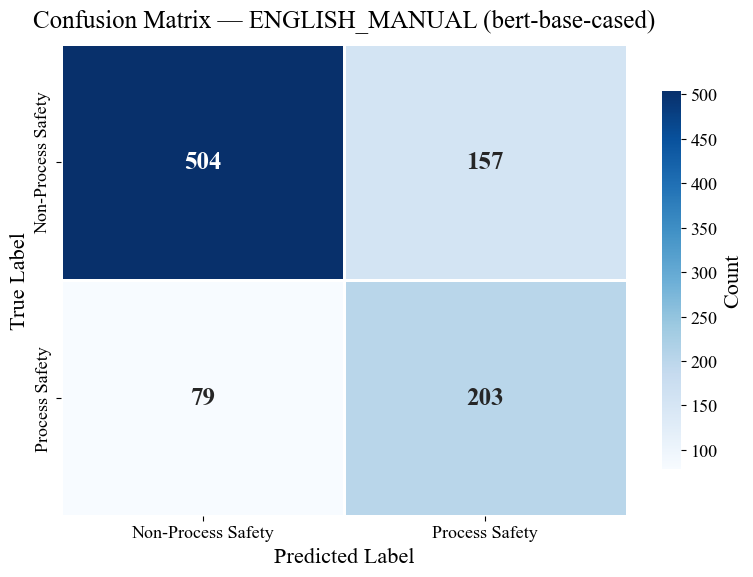


Training SVM: GERMANY_MANUAL | Model: bert-base-cased
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 3.49s

Accuracy: 0.7640
F1 Score (weighted): 0.7975
F1 Score (macro): 0.5879

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9270    0.7973    0.8573      2659
    Process Safety     0.2344    0.4970    0.3185       332

          accuracy                         0.7640      2991
         macro avg     0.5807    0.6471    0.5879      2991
      weighted avg     0.8501    0.7640    0.7975      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_bert-base-cased


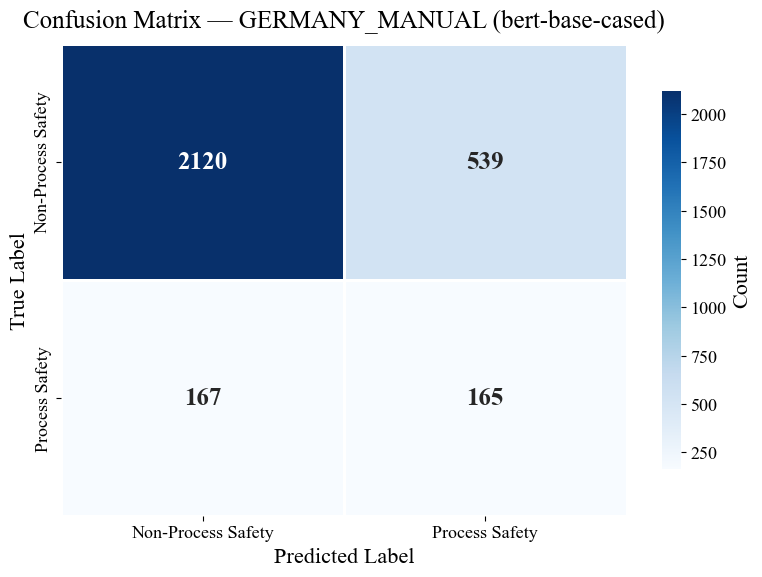


Training SVM: SWEDEN_MANUAL | Model: bert-base-cased
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 12.92s

Accuracy: 0.8466
F1 Score (weighted): 0.8689
F1 Score (macro): 0.5492

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9472    0.8856    0.9154      2290
    Process Safety     0.1382    0.2710    0.1830       155

          accuracy                         0.8466      2445
         macro avg     0.5427    0.5783    0.5492      2445
      weighted avg     0.8959    0.8466    0.8689      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_bert-base-cased


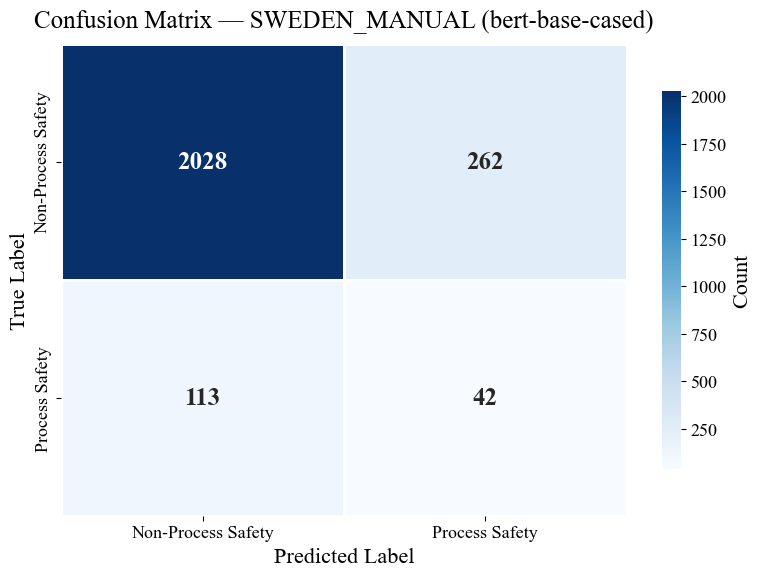


Training SVM: NETHERLANDS_MANUAL | Model: bert-base-cased
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 3.06s

Accuracy: 0.6683
F1 Score (weighted): 0.6714
F1 Score (macro): 0.6099

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7721    0.7500    0.7609       280
    Process Safety     0.4444    0.4746    0.4590       118

          accuracy                         0.6683       398
         macro avg     0.6083    0.6123    0.6099       398
      weighted avg     0.6749    0.6683    0.6714       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_bert-base-cased


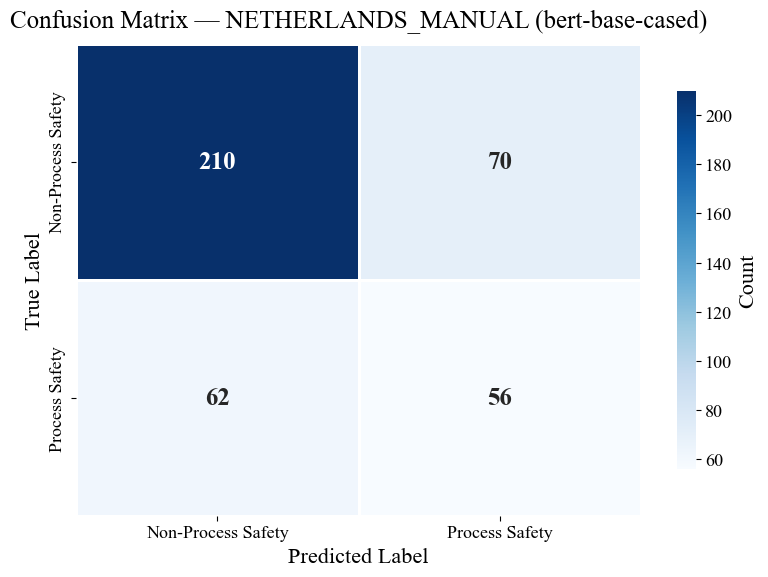


 Processing complete bert-base-cased

################################################################################
MODEL: bert-large-cased (bert-large-cased)
################################################################################

Initializing bert-large-cased...
Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-large-cased

[SKIP] Embeddings already exist: english_manual | Model: bert-large-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/english_manual_bert-large-cased_embeddings.pkl
Checkpoint saved. Progress: 5/24

[SKIP] Embeddings already exist: germany_manual | Model: bert-large-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/germany_manual_bert-large-cased_embeddings.pkl
Checkpoint saved. Progress: 6/24

[SKIP] Embeddings already exist: sweden_manual | Model: bert-large-cased
  Using cached: /Users/shari

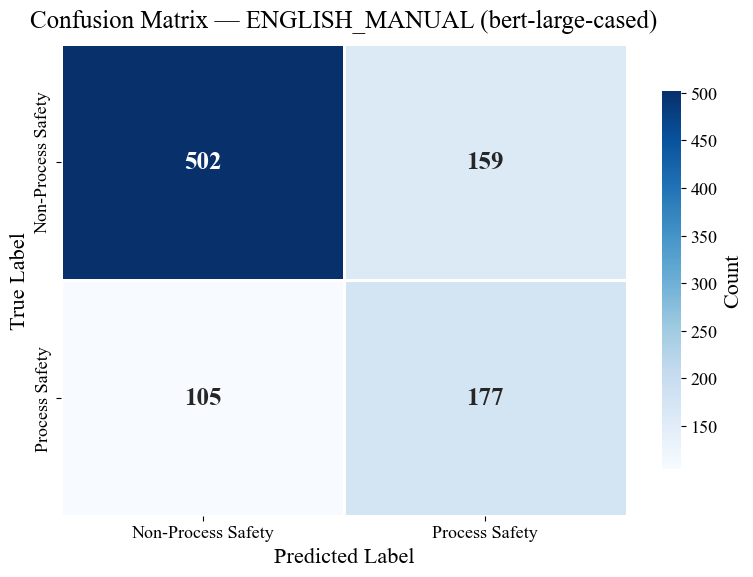


Training SVM: GERMANY_MANUAL | Model: bert-large-cased
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 34.07s

Accuracy: 0.7920
F1 Score (weighted): 0.8126
F1 Score (macro): 0.5825

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9155    0.8439    0.8783      2659
    Process Safety     0.2315    0.3765    0.2867       332

          accuracy                         0.7920      2991
         macro avg     0.5735    0.6102    0.5825      2991
      weighted avg     0.8396    0.7920    0.8126      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_bert-large-cased


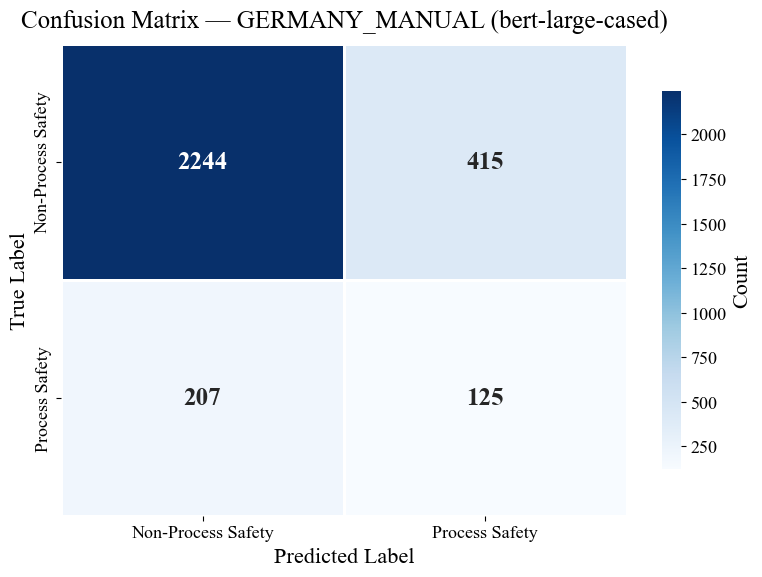


Training SVM: SWEDEN_MANUAL | Model: bert-large-cased
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 19.79s

Accuracy: 0.8618
F1 Score (weighted): 0.8773
F1 Score (macro): 0.5521

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9461    0.9039    0.9245      2290
    Process Safety     0.1440    0.2387    0.1796       155

          accuracy                         0.8618      2445
         macro avg     0.5450    0.5713    0.5521      2445
      weighted avg     0.8952    0.8618    0.8773      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_bert-large-cased


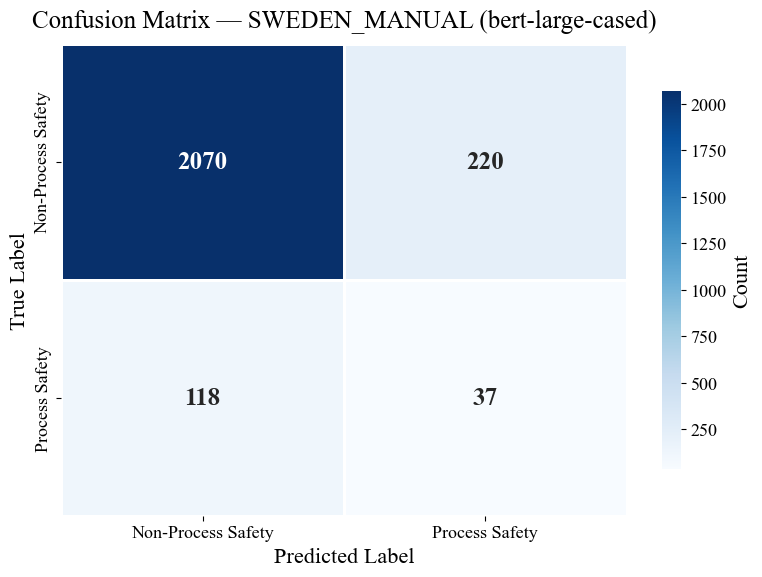


Training SVM: NETHERLANDS_MANUAL | Model: bert-large-cased
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 12.47s

Accuracy: 0.6005
F1 Score (weighted): 0.6010
F1 Score (macro): 0.5223

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7168    0.7143    0.7156       280
    Process Safety     0.3277    0.3305    0.3291       118

          accuracy                         0.6005       398
         macro avg     0.5223    0.5224    0.5223       398
      weighted avg     0.6015    0.6005    0.6010       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_bert-large-cased


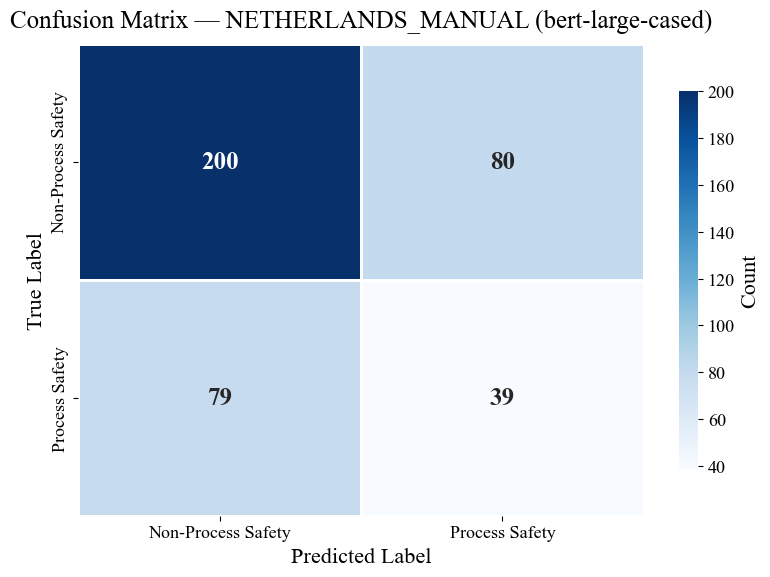


 Processing complete bert-large-cased

################################################################################
MODEL: roberta-base (roberta-base)
################################################################################

Initializing roberta-base...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-base

[SKIP] Embeddings already exist: english_manual | Model: roberta-base
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/english_manual_roberta-base_embeddings.pkl
Checkpoint saved. Progress: 9/24

[SKIP] Embeddings already exist: germany_manual | Model: roberta-base
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/germany_manual_roberta-base_embeddings.pkl
Checkpoint saved. Progress: 10/24

[SKIP] Embeddings already exist: sweden_manual | Model: roberta-base
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/sweden_manual_roberta-base_embeddings.pkl
Checkpoint saved. Progress: 11/24

[SKIP] Embeddings already exist: netherlands_manual | Model: roberta-base
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026

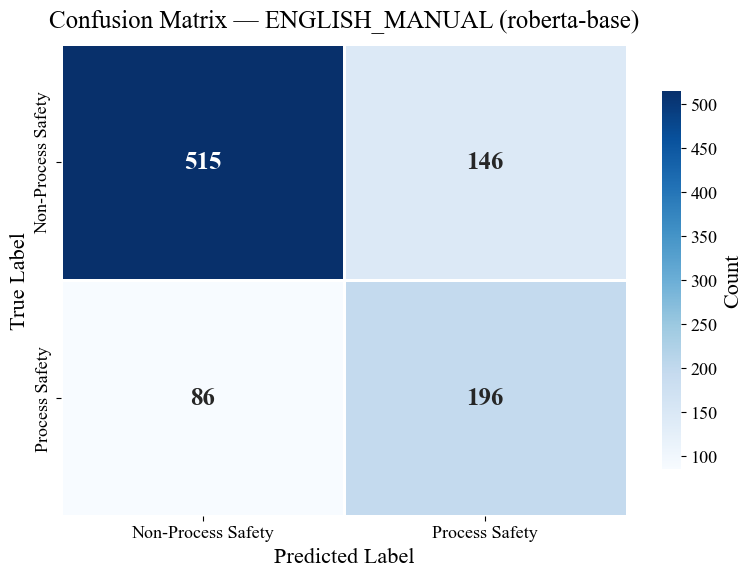


Training SVM: GERMANY_MANUAL | Model: roberta-base
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 7.08s

Accuracy: 0.7894
F1 Score (weighted): 0.8169
F1 Score (macro): 0.6169

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9337    0.8214    0.8739      2659
    Process Safety     0.2715    0.5331    0.3598       332

          accuracy                         0.7894      2991
         macro avg     0.6026    0.6772    0.6169      2991
      weighted avg     0.8602    0.7894    0.8169      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_roberta-base


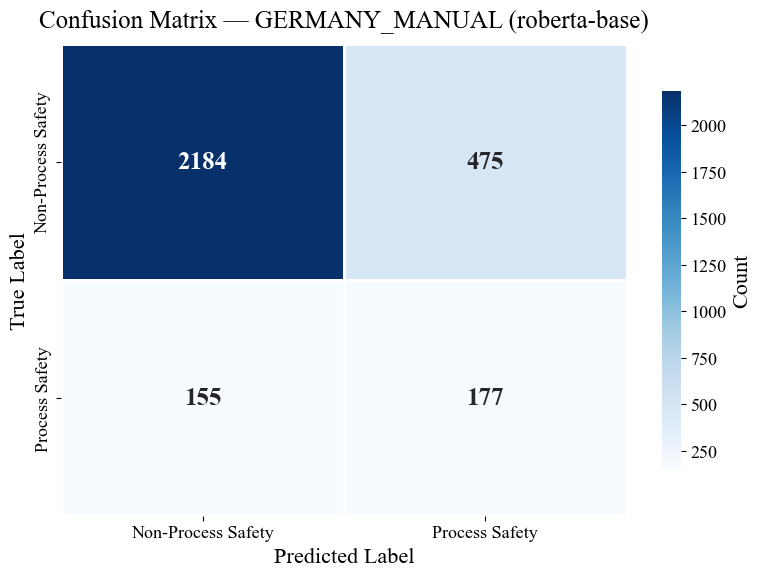


Training SVM: SWEDEN_MANUAL | Model: roberta-base
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 18.09s

Accuracy: 0.8560
F1 Score (weighted): 0.8756
F1 Score (macro): 0.5640

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9494    0.8939    0.9208      2290
    Process Safety     0.1592    0.2968    0.2072       155

          accuracy                         0.8560      2445
         macro avg     0.5543    0.5953    0.5640      2445
      weighted avg     0.8993    0.8560    0.8756      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_roberta-base


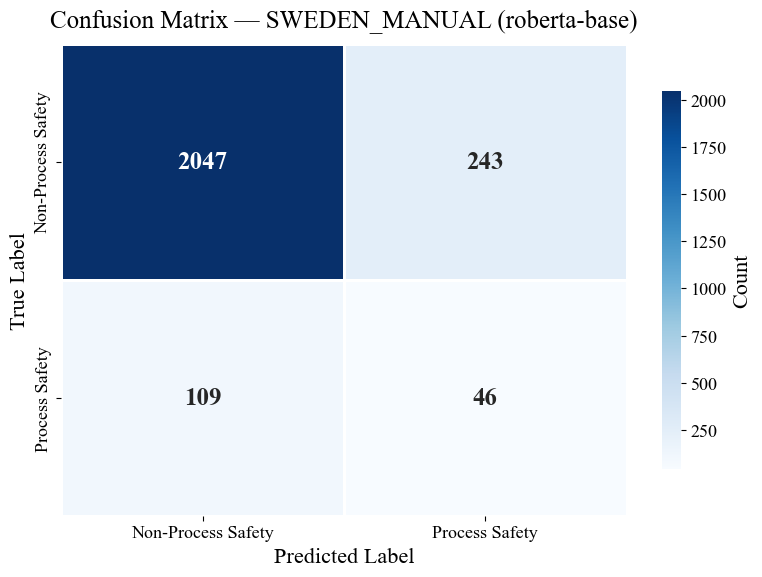


Training SVM: NETHERLANDS_MANUAL | Model: roberta-base
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 2.13s

Accuracy: 0.6985
F1 Score (weighted): 0.7013
F1 Score (macro): 0.6454

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7941    0.7714    0.7826       280
    Process Safety     0.4921    0.5254    0.5082       118

          accuracy                         0.6985       398
         macro avg     0.6431    0.6484    0.6454       398
      weighted avg     0.7046    0.6985    0.7013       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_roberta-base


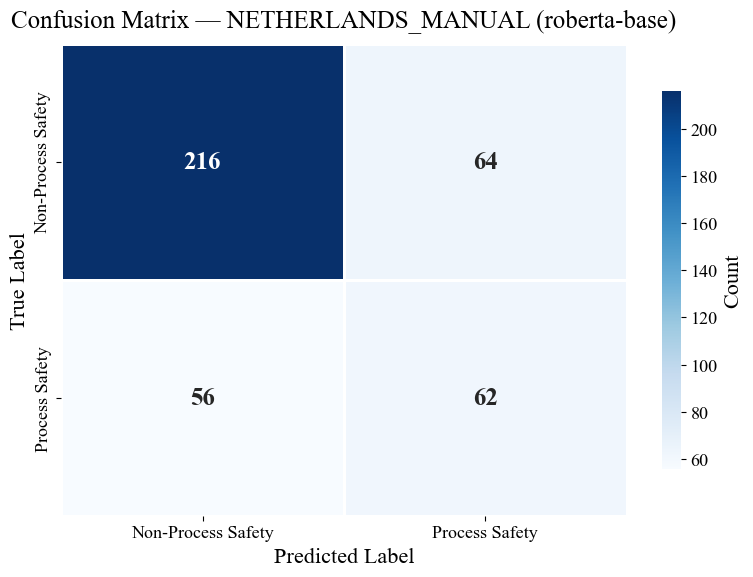


 Processing complete roberta-base

################################################################################
MODEL: roberta-large (roberta-large)
################################################################################

Initializing roberta-large...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-large

[SKIP] Embeddings already exist: english_manual | Model: roberta-large
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-large/english_manual_roberta-large_embeddings.pkl
Checkpoint saved. Progress: 13/24

[SKIP] Embeddings already exist: germany_manual | Model: roberta-large
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-large/germany_manual_roberta-large_embeddings.pkl
Checkpoint saved. Progress: 14/24

[SKIP] Embeddings already exist: sweden_manual | Model: roberta-large
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-large/sweden_manual_roberta-large_embeddings.pkl
Checkpoint saved. Progress: 15/24

[SKIP] Embeddings already exist: netherlands_manual | Model: roberta-large
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/mast

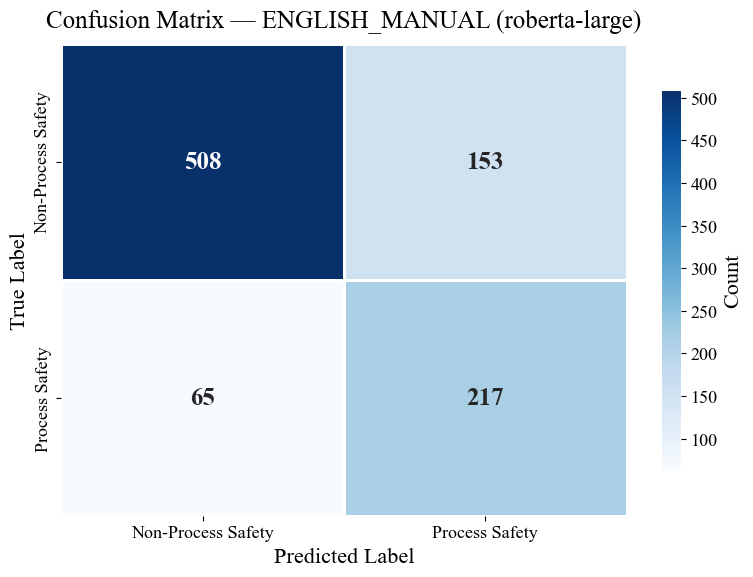


Training SVM: GERMANY_MANUAL | Model: roberta-large
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 60.24s

Accuracy: 0.8108
F1 Score (weighted): 0.8326
F1 Score (macro): 0.6384

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9366    0.8443    0.8881      2659
    Process Safety     0.3030    0.5422    0.3888       332

          accuracy                         0.8108      2991
         macro avg     0.6198    0.6932    0.6384      2991
      weighted avg     0.8663    0.8108    0.8326      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_roberta-large


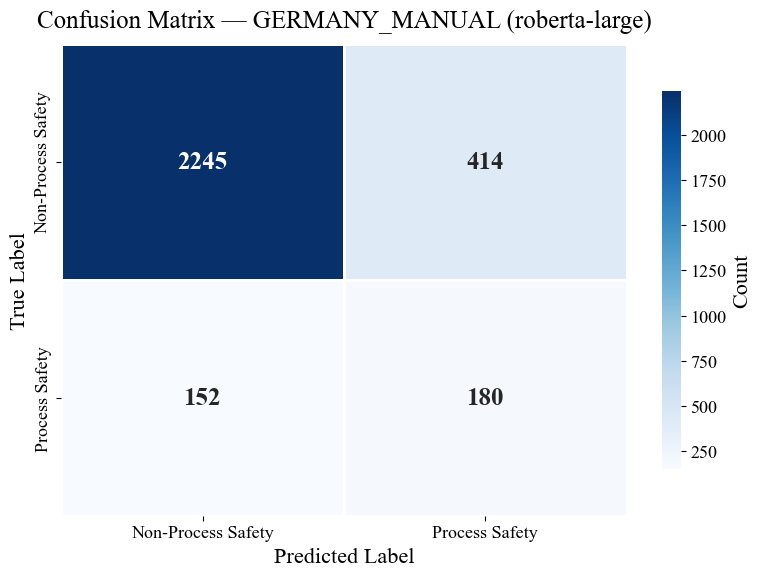


Training SVM: SWEDEN_MANUAL | Model: roberta-large
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 23.35s

Accuracy: 0.8671
F1 Score (weighted): 0.8835
F1 Score (macro): 0.5830

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9521    0.9035    0.9272      2290
    Process Safety     0.1875    0.3290    0.2389       155

          accuracy                         0.8671      2445
         macro avg     0.5698    0.6163    0.5830      2445
      weighted avg     0.9037    0.8671    0.8835      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_roberta-large


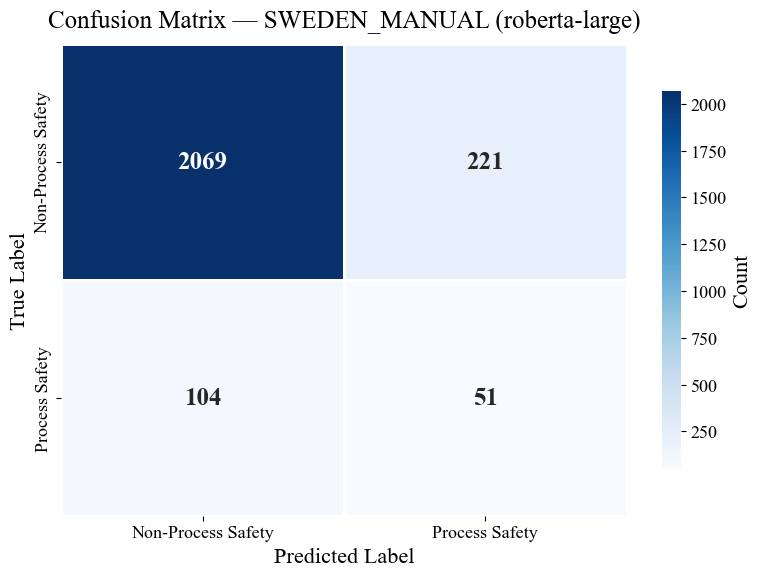


Training SVM: NETHERLANDS_MANUAL | Model: roberta-large
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 6.07s

Accuracy: 0.6784
F1 Score (weighted): 0.6820
F1 Score (macro): 0.6235

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7815    0.7536    0.7673       280
    Process Safety     0.4609    0.5000    0.4797       118

          accuracy                         0.6784       398
         macro avg     0.6212    0.6268    0.6235       398
      weighted avg     0.6864    0.6784    0.6820       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_roberta-large


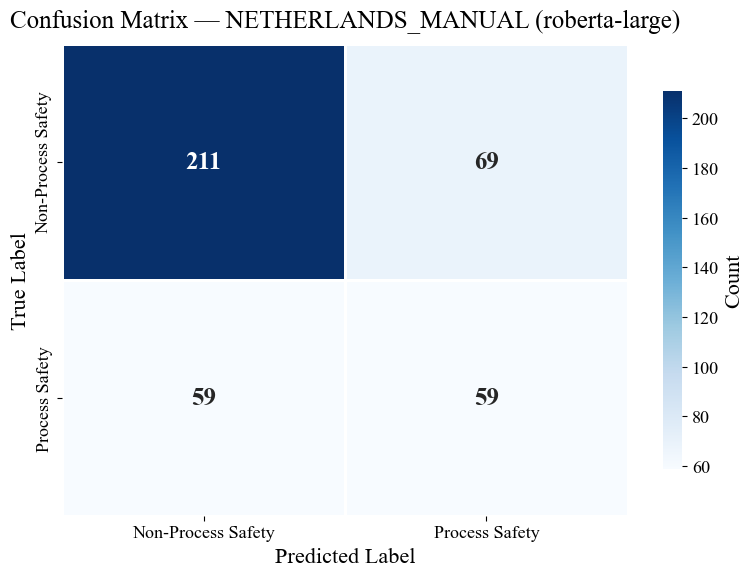


 Processing complete roberta-large

################################################################################
MODEL: distilbert-base-cased (distilbert-base-cased)
################################################################################

Initializing distilbert-base-cased...
Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - distilbert-base-cased

[SKIP] Embeddings already exist: english_manual | Model: distilbert-base-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/distilbert-base-cased/english_manual_distilbert-base-cased_embeddings.pkl
Checkpoint saved. Progress: 17/24

[SKIP] Embeddings already exist: germany_manual | Model: distilbert-base-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/distilbert-base-cased/germany_manual_distilbert-base-cased_embeddings.pkl
Checkpoint saved. Progress: 18/24

[SKIP] Embeddings already exist: sweden_manual | Mo

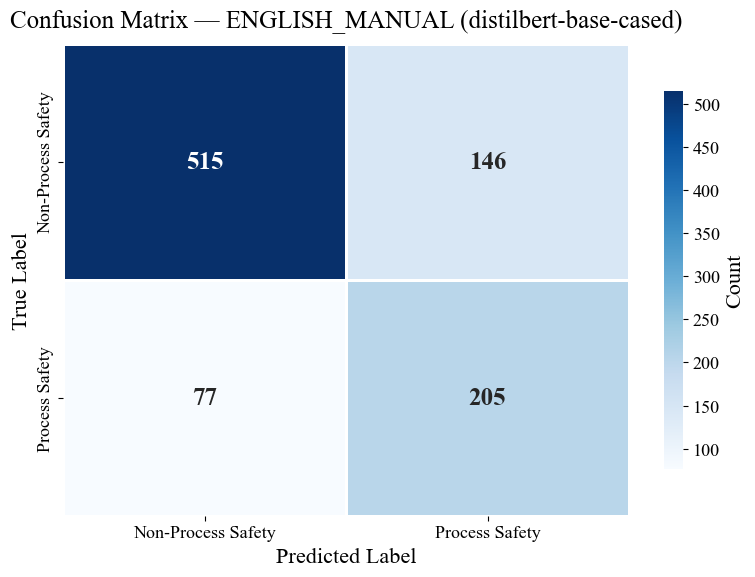


Training SVM: GERMANY_MANUAL | Model: distilbert-base-cased
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 11.90s

Accuracy: 0.7981
F1 Score (weighted): 0.8224
F1 Score (macro): 0.6201

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9319    0.8338    0.8801      2659
    Process Safety     0.2778    0.5120    0.3602       332

          accuracy                         0.7981      2991
         macro avg     0.6048    0.6729    0.6201      2991
      weighted avg     0.8593    0.7981    0.8224      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_distilbert-base-cased


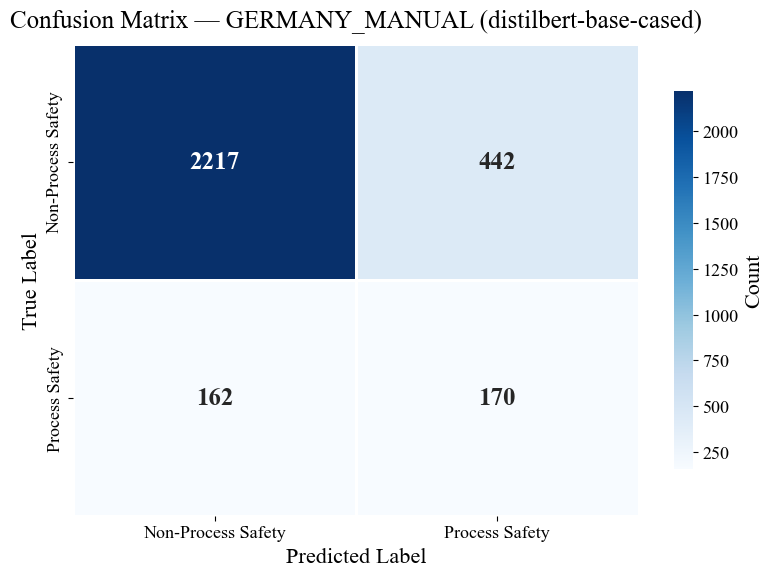


Training SVM: SWEDEN_MANUAL | Model: distilbert-base-cased
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 18.99s

Accuracy: 0.8609
F1 Score (weighted): 0.8783
F1 Score (macro): 0.5647

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9489    0.9000    0.9238      2290
    Process Safety     0.1612    0.2839    0.2056       155

          accuracy                         0.8609      2445
         macro avg     0.5550    0.5919    0.5647      2445
      weighted avg     0.8990    0.8609    0.8783      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_distilbert-base-cased


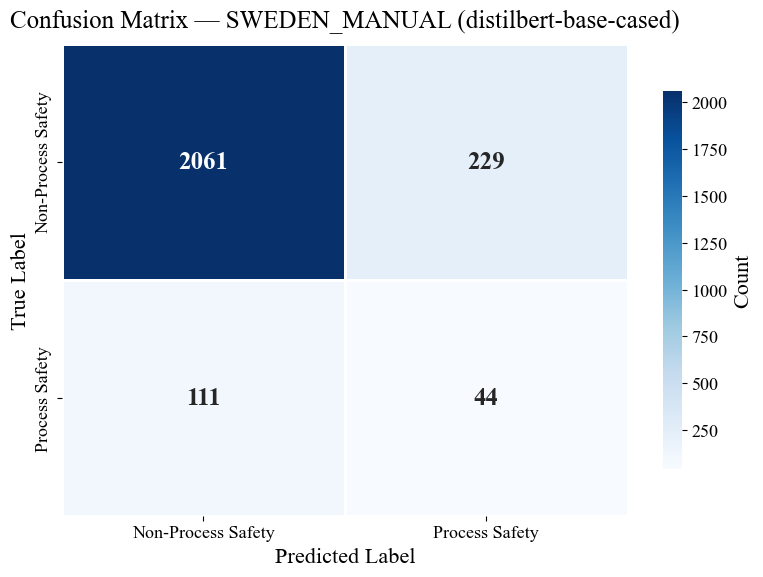


Training SVM: NETHERLANDS_MANUAL | Model: distilbert-base-cased
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 3.75s

Accuracy: 0.6558
F1 Score (weighted): 0.6517
F1 Score (macro): 0.5779

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7474    0.7714    0.7592       280
    Process Safety     0.4128    0.3814    0.3965       118

          accuracy                         0.6558       398
         macro avg     0.5801    0.5764    0.5779       398
      weighted avg     0.6482    0.6558    0.6517       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_distilbert-base-cased


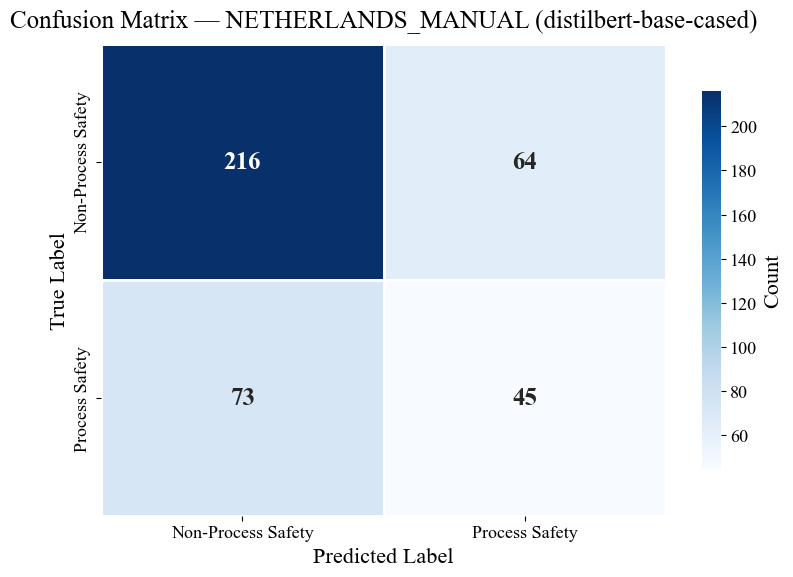


 Processing complete distilbert-base-cased

################################################################################
MODEL: xlnet-base-cased (xlnet-base-cased)
################################################################################

Initializing xlnet-base-cased...
Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - xlnet-base-cased

[SKIP] Embeddings already exist: english_manual | Model: xlnet-base-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/xlnet-base-cased/english_manual_xlnet-base-cased_embeddings.pkl
Checkpoint saved. Progress: 21/24

[SKIP] Embeddings already exist: germany_manual | Model: xlnet-base-cased
  Using cached: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/xlnet-base-cased/germany_manual_xlnet-base-cased_embeddings.pkl
Checkpoint saved. Progress: 22/24

[SKIP] Embeddings already exist: sweden_manual | Model: xlnet-base-cased
  Using cached: /Use

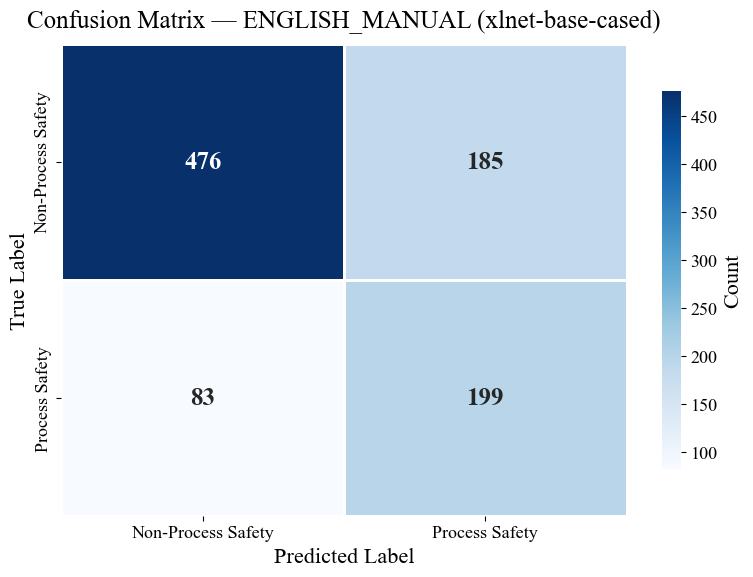


Training SVM: GERMANY_MANUAL | Model: xlnet-base-cased
Training samples: 6000
Test samples: 2991
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...
Training completed in 2.24s

Accuracy: 0.7496
F1 Score (weighted): 0.7852
F1 Score (macro): 0.5631

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9178    0.7890    0.8485      2659
    Process Safety     0.2043    0.4337    0.2777       332

          accuracy                         0.7496      2991
         macro avg     0.5610    0.6114    0.5631      2991
      weighted avg     0.8386    0.7496    0.7852      2991


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_germany_manual_xlnet-base-cased


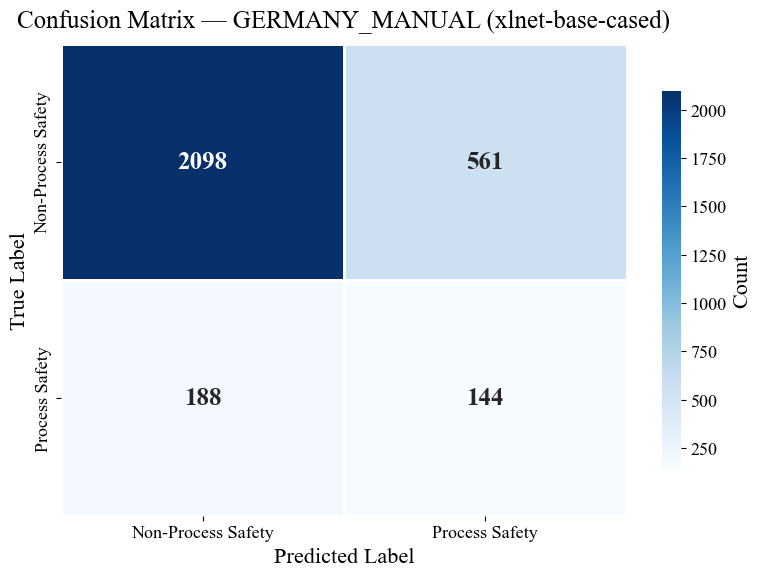


Training SVM: SWEDEN_MANUAL | Model: xlnet-base-cased
Training samples: 6000
Test samples: 2445
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 18.59s

Accuracy: 0.8319
F1 Score (weighted): 0.8611
F1 Score (macro): 0.5509

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9497    0.8664    0.9061      2290
    Process Safety     0.1404    0.3226    0.1957       155

          accuracy                         0.8319      2445
         macro avg     0.5451    0.5945    0.5509      2445
      weighted avg     0.8984    0.8319    0.8611      2445


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_sweden_manual_xlnet-base-cased


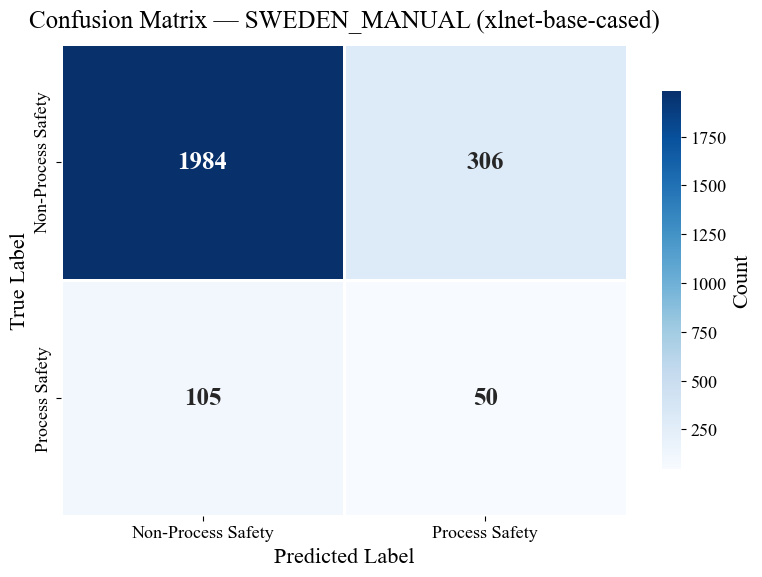


Training SVM: NETHERLANDS_MANUAL | Model: xlnet-base-cased
Training samples: 1592
Test samples: 398
Applied StandardScaler to embeddings.

Training LinearSVC (max 300s)...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 8.47s

Accuracy: 0.6156
F1 Score (weighted): 0.6210
F1 Score (macro): 0.5529

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7378    0.7036    0.7203       280
    Process Safety     0.3664    0.4068    0.3855       118

          accuracy                         0.6156       398
         macro avg     0.5521    0.5552    0.5529       398
      weighted avg     0.6277    0.6156    0.6210       398


[OK] Saved confusion matrix PNG + PDF: confusion_matrix_netherlands_manual_xlnet-base-cased


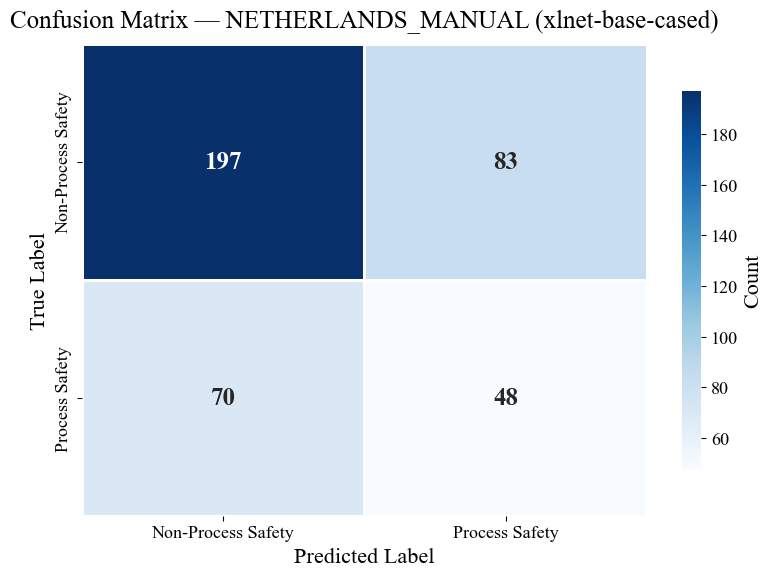


 Processing complete xlnet-base-cased

################################################################################
FINAL SUMMARY
################################################################################

DETAILED RESULTS TABLE
           dataset                 model  accuracy  f1_weighted  f1_macro  precision_non_ps  recall_non_ps  f1_non_ps  support_non_ps  precision_ps  recall_ps    f1_ps  support_ps  training_time  subsampled
    english_manual       bert-base-cased  0.749735     0.757092  0.721344          0.864494       0.762481   0.810289             661      0.563889   0.719858 0.632399         282       0.930568       False
    germany_manual       bert-base-cased  0.763959     0.797460  0.587896          0.926979       0.797292   0.857258            2659      0.234375   0.496988 0.318533         332       3.491650        True
     sweden_manual       bert-base-cased  0.846626     0.868941  0.549188          0.947221       0.885590   0.915369            2290      

In [9]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time


# ============================================================
# Configuration
# ============================================================

# Use PATHS from earlier configuration (already cross-platform)
DATA_DIR = str(PATHS['master_dataset'] / 'By_SL_Country')
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint_iteration_2.json")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations
MODELS = {
    'bert-base-cased': 'bert-base-cased',
    'bert-large-cased': 'bert-large-cased',
    'roberta-base': 'roberta-base',
    'roberta-large': 'roberta-large',
    'distilbert-base-cased': 'distilbert-base-cased',
    'xlnet-base-cased': 'xlnet-base-cased'
}

# Datasets to skip
SKIP_DATASETS = [
    'master_df_Hungary_manual.json',
    'master_df_International_manual.json',
    'master_df_Russia_manual.json',
    'master_df_UAE_manual.json',
    'master_df_Poland_manual.json',
    'master_df_Unknown_manual.json',
]

# Timeout and memory management settings
MAX_PROCESSING_TIME = 3600 * 3  # 3 hours in seconds
BATCH_SIZE = 12  # Reduce to prevent memory issues
SVM_TIMEOUT = 300  # 5 minutes timeout for SVM training
MAX_SAMPLES_SVM = 6000  # Limit samples for large datasets 

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

# ============================================================
# Functions
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=12):
    """Generate BERT embeddings for a list of texts with memory management"""
    embeddings = []
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'mps':
            torch.mps.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)


def process_dataset(json_file, model_name, model_key, tokenizer, model, dataset_name=None):
    """Process a single JSON dataset and save embeddings. Skips if cached."""
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    # Check for existing cached embeddings
    model_short_name = model_name.replace('/', '_')
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name)
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_short_name}_embeddings.pkl')
    
    if os.path.exists(pkl_file):
        print(f"\n{'='*80}")
        print(f"[SKIP] Embeddings already exist: {dataset_name} | Model: {model_key}")
        print(f"{'='*80}")
        print(f"  Using cached: {pkl_file}")
        return pkl_file
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name} | Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset from Iteration 0 pre-processed JSON (no re-preprocessing needed)
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\nWARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_short_name = model_name.replace('/', '_')
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name)
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings (save both full and subset)
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_short_name}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory after processing
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return pkl_file


def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_name = metadata['model']
    model_key = metadata.get('model_key', model_name)
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    # Use faster LinearSVC instead of SVC with timeout protection
    try:
        from sklearn.svm import LinearSVC
        from sklearn.preprocessing import StandardScaler
        from sklearn.metrics import precision_recall_fscore_support
        
        # StandardScaler: normalize embeddings before SVM (consistent with iter 0 & 1)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        print("Applied StandardScaler to embeddings.")
        
        print(f"\nTraining LinearSVC (max {SVM_TIMEOUT}s)...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Figure styling (consistent with Iteration 0 & 1)
        plt.rcParams.update({
            'font.family': 'serif',
            'font.serif': ['Times New Roman'],
            'font.size': 14,
            'axes.labelsize': 16,
            'axes.titlesize': 18,
            'xtick.labelsize': 13,
            'ytick.labelsize': 13,
        })
        
        fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Process Safety', 'Process Safety'],
            yticklabels=['Non-Process Safety', 'Process Safety'],
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Count'},
            ax=ax_cm
        )
        ax_cm.set_xlabel('Predicted Label', fontsize=16, fontfamily='serif')
        ax_cm.set_ylabel('True Label', fontsize=16, fontfamily='serif')
        ax_cm.set_title(
            f'Confusion Matrix — {dataset_name.upper()} ({model_key})',
            fontsize=18, fontfamily='serif', pad=12
        )
        fig_cm.tight_layout()
        
        # Save as separate PNG + PDF with high resolution
        png_path = os.path.join(RESULTS_DIR, f'confusion_matrix_{dataset_name}_{model_key}.png')
        pdf_path = os.path.join(RESULTS_DIR, f'confusion_matrix_{dataset_name}_{model_key}.pdf')
        fig_cm.savefig(png_path, dpi=300, bbox_inches='tight')
        fig_cm.savefig(pdf_path, bbox_inches='tight')
        print(f"\n[OK] Saved confusion matrix PNG + PDF: confusion_matrix_{dataset_name}_{model_key}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': model_name,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            # Non-Process Safety (class 0) metrics
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            # Process Safety (class 1) metrics
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\nERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise


# ============================================================
# Main Execution
# ============================================================
print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)

# Use JSON dataset files defined in Cell 2 (from Iteration 0 outputs)
json_files = list(DATASET_FILES.items())  # [(name, path), ...]

print(f"\nDatasets to process: {len(json_files)}")
for name, path in json_files:
    print(f"  {name}: {os.path.basename(path)}")
print(f"\nFound {len(MODELS)} models to use")
print(f"Total combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"Already processed: {len(processed_items)} combinations")

# Track all results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        print(f"Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files:
            # dataset_name is already the key from DATASET_FILES dict
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\nSkipping already processed: {dataset_name} with {model_key}")
                model_short_name = model_name.replace('/', '_')
                pkl_file = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name, 
                                       f'{dataset_name}_{model_short_name}_embeddings.pkl')
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            # Check timeout
            elapsed_time = time.time() - start_time
            if elapsed_time > MAX_PROCESSING_TIME:
                print(f"\nReached time limit ({MAX_PROCESSING_TIME/60:.1f} minutes).")
                print(f"Resume by running this cell again - checkpoint saved.")
                break
            
            try:
                # Always pass dataset_name explicitly to avoid local variable errors
                pkl_file = process_dataset(json_file, model_name, model_key, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Checkpoint saved. Progress: {len(processed_items)}/{len(json_files) * len(MODELS)}")
                
            except Exception as e:
                print(f"✗ ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f"ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        
        print(f"\n Processing complete {model_key}")
        
    except Exception as e:
        print(f"\nERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display DETAILED results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    # Check which columns exist
    # Format the detailed table
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps'
    ]
    
    # Check which columns exist
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    
    if 'training_time' in results_df.columns:
        display_cols.append('training_time')
    if 'subsampled' in results_df.columns:
        display_cols.append('subsampled')
    
    # Create a formatted display DataFrame
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns for better display
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    print(display_df.to_string(index=False))
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    # Create a formatted classification report style table
    print(display_df.to_string(index=False))
    
    # Save detailed results to JSON
    summary_file = os.path.join(RESULTS_DIR, 'all_models_svm_detailed_results.json')
    results_df.to_json(summary_file, orient='records', indent=2)
    print(f"\nDetailed results saved to: {summary_file}")
    
    # Create a formatted classification report style table
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING MODEL (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best by F1 for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Results by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Results by dataset
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY DATASET")
        print(f"{'='*80}")
        dataset_stats = results_df.groupby('dataset')[['accuracy', 'f1_weighted', 'f1_macro',
                                                         'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(dataset_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(json_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print("ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)

if all_results:
    _results_df = pd.DataFrame(all_results)
    _RQ1_TARGET = 0.85
    _RQ1_BASELINE = 0.7825
    _best_idx = _results_df['f1_macro'].idxmax() if 'f1_macro' in _results_df.columns else 0

    _summary = {
        'iteration': 2,
        'model': '6 BERT-family models (bert-base-cased, bert-large-cased, roberta-base, '
                 'roberta-large, distilbert-base-cased, xlnet-base-cased) + LinearSVC',
        'baseline_macro_f1': _RQ1_BASELINE,
        'best_dataset': str(_results_df.loc[_best_idx, 'dataset']) if len(_results_df) > 0 else '',
        'best_model':   str(_results_df.loc[_best_idx, 'model']) if len(_results_df) > 0 else '',
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row.get('model', 'unknown')}"
        _f1_macro = float(row.get('f1_macro', 0))
        _summary['datasets'][key] = {
            'results': {
                'accuracy':     round(float(row.get('accuracy', 0)), 4),
                'macro_f1':     round(_f1_macro, 4),
                'precision_ps': round(float(row.get('precision_ps', 0)), 4),
                'recall_ps':    round(float(row.get('recall_ps', 0)), 4),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_macro_f1': round(_f1_macro, 4),
            'baseline_macro_f1': _RQ1_BASELINE,
            'improvement_over_baseline': round(_f1_macro - _RQ1_BASELINE, 4),
            'rq1_target': _RQ1_TARGET,
            'gap': round(float(_RQ1_TARGET - _f1_macro), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_2_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as f:
        json.dump(_summary, f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")